<a href="https://colab.research.google.com/github/MarlzRana/machine-learning/blob/main/experiment_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Augmentation Experiment

## Imports

External imports

In [ ]:
import albumentations as A

import torch

from torchvision import transforms

from matplotlib import pyplot as plt

Internal imports

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/dataset.ipynb"

### Define Ex-Transformations

In [ ]:
img_transform = transforms.Compose(
    [
        transforms.Resize(size=(352, 352), antialias=True),
        lambda x: x.to(torch.float) / 255,
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

In [ ]:
msk_transform = transforms.Compose(
    [
        transforms.Resize(size=(352, 352), antialias=True),
    ]
)

## Load Test Dataset

In [ ]:
ds = MultipleSegmentationDatasetsSeperateMsks(
  dataset_map={
    "kitti": {
      "img_dir": "/content/drive/My Drive/datasets/kitti/train/imgs",
      "msk_dir": "/content/drive/My Drive/datasets/kitti/train/msks",
      "img_to_msk_file_name": lambda x: x,
      },
    },
  label_map={
    "road": 0,
    "sidewalk": 1,
    "building": 2,
    "wall": 3,
    "fence": 4,
    "pole": 5,
    "traffic_light": 6,
    "traffic_sign": 7,
    "vegetation": 8,
    "terrain": 9,
    "sky": 10,
    "person": 11,
    "rider": 12,
    "car": 13,
    "truck": 14,
    "bus": 15,
    "train": 16,
    "motorcycle": 17,
    "bicycle": 18
  },
)

In [ ]:
smp_img, smp_msk = ds[0]

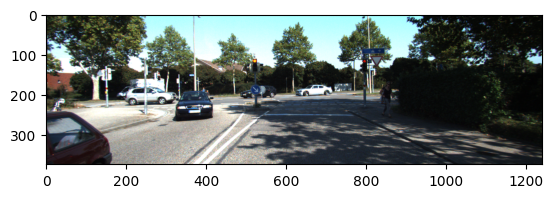

In [ ]:
plt.imshow(smp_img.permute(1, 2, 0))

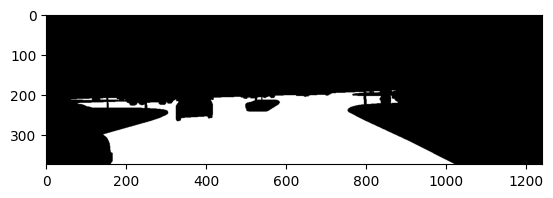

In [ ]:
plt.imshow(smp_msk[0].unsqueeze(0).permute(1, 2, 0), cmap="gray")

## Experimentings with transformations from the Albumentation library

In [ ]:
joint_tr_A = A.Compose(
  [
    A.Resize(width=352, height=352),
  ]
)

In [ ]:
img_post_tr_A = A.Compose(
    [
        A.Normalize(mean=0.0, std=1.0), # 0/1 Normalization
        # A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=1) #ImageNet Normalization
    ]
)

In [ ]:
import os

import torch

from torch.utils.data import Dataset
from torchvision.io import read_image

import matplotlib.pyplot as plt

import cv2

import numpy as np

import cv2

img_post_tr_A = A.Compose(
    [
        A.Normalize(mean=0.0, std=1.0), # 0/1 Normalization
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=1) #ImageNet Normalization
    ]
)

class MultipleSegmentationDatasetsSeperateMsks(Dataset):
  def __init__(self, dataset_map, label_map, joint_tr=None, img_post_tr=None, msk_post_tr=None, msk_type=torch.float):
    self.dataset_map = dataset_map
    self.label_map = label_map
    self.joint_tr = joint_tr
    self.img_post_tr = img_post_tr
    self.msk_post_tr = msk_post_tr
    self.msk_type = msk_type
    self.dataset_idx_range_map = {}
    self.length = 0

    index_begin = 0
    for dataset_name, dataset_attrs in self.dataset_map.items():
      ids = os.listdir(dataset_attrs["img_dir"])
      dataset_attrs["ids"] = ids
      self.dataset_idx_range_map[(index_begin, index_begin + len(ids))] = dataset_name
      index_begin += len(ids)

    self.length = index_begin

  def __len__(self):
    return self.length

  def __getitem__(self, idx):
    src_dataset_name = None
    idx_offset = 0

    for dataset_index_range, dataset_name in self.dataset_idx_range_map.items():
      if (idx in range(*dataset_index_range)):
        src_dataset_name = dataset_name
        idx_offset = dataset_index_range[0]

    img_path = os.path.join(self.dataset_map[src_dataset_name]["img_dir"], self.dataset_map[src_dataset_name]["ids"][idx - idx_offset])
    msk_path = os.path.join(self.dataset_map[src_dataset_name]["msk_dir"], self.dataset_map[src_dataset_name]["img_to_msk_file_name"](self.dataset_map[src_dataset_name]["ids"][idx - idx_offset]))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

    msks = [(msk == pixel_color) for pixel_color in self.label_map.values()]
    msk = np.stack(msks, axis=-1).astype("float")

    if self.joint_tr:
      out_joint_tr = self.joint_tr(image=img, mask=msk)
      img, msk = out_joint_tr["image"], out_joint_tr["mask"]

    if self.img_post_tr:
      out_img_post_tr = self.img_post_tr(image=img)
      img = out_img_post_tr["image"]

    if self.msk_post_tr:
      out_msk_post_tr = self.msk_post_tr(mask=msk)
      msk = out_msk_post_tr["mask"]

    return img, msk

  def get_unprocessed(self, idx):
    src_dataset_name = None
    idx_offset = 0

    for dataset_index_range, dataset_name in self.dataset_idx_range_map.items():
      if (idx in range(*dataset_index_range)):
        src_dataset_name = dataset_name
        idx_offset = dataset_index_range[0]

    img_path = os.path.join(self.dataset_map[src_dataset_name]["img_dir"], self.dataset_map[src_dataset_name]["ids"][idx - idx_offset])
    msk_path = os.path.join(self.dataset_map[src_dataset_name]["msk_dir"], self.dataset_map[src_dataset_name]["img_to_msk_file_name"](self.dataset_map[src_dataset_name]["ids"][idx - idx_offset]))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

    return img, msk


ds = MultipleSegmentationDatasetsSeperateMsks(
  dataset_map={
    "kitti": {
      "img_dir": "/content/drive/My Drive/datasets/kitti/train/imgs",
      "msk_dir": "/content/drive/My Drive/datasets/kitti/train/msks",
      "img_to_msk_file_name": lambda x: x,
      },
    },
  label_map={
    "road": 0,
    "sidewalk": 1,
    "building": 2,
    "wall": 3,
    "fence": 4,
    "pole": 5,
    "traffic_light": 6,
    "traffic_sign": 7,
    "vegetation": 8,
    "terrain": 9,
    "sky": 10,
    "person": 11,
    "rider": 12,
    "car": 13,
    "truck": 14,
    "bus": 15,
    "train": 16,
    "motorcycle": 17,
    "bicycle": 18
  },
  joint_tr=joint_tr_A,
  img_post_tr=img_post_tr_A
)

smp_img, smp_msk = ds[0]

smp_img

array([[[-1.7925336 , -1.580532  , -1.5255774 ],
        [-1.1589177 , -0.96778697, -1.1944226 ],
        [-1.1931672 , -1.037815  , -1.3338561 ],
        ...,
        [-1.9295317 , -1.598039  , -1.5255774 ],
        [-0.55955136, -0.3025208 ,  0.80993485],
        [-1.843908  , -1.7380952 , -1.0724183 ]],

       [[-1.7069099 , -1.563025  , -1.5604358 ],
        [-1.1589177 , -0.915266  , -0.96784306],
        [-1.3301654 , -1.020308  , -1.3338561 ],
        ...,
        [-1.278791  , -0.58263296, -1.0201308 ],
        [-0.43967795, -0.42506996,  0.374205  ],
        [-1.843908  , -1.7205881 , -1.403573  ]],

       [[-1.6384109 , -1.545518  , -1.5430065 ],
        [-1.2959157 , -1.0553219 , -1.1769934 ],
        [-1.5185376 , -1.177871  , -1.3512853 ],
        ...,
        [-0.88492167,  0.04761919,  0.3219174 ],
        [-1.4671634 , -1.160364  , -0.32296288],
        [-1.9637812 , -1.7380952 , -1.5430065 ]],

       ...,

       [[-1.6212862 , -1.7731091 , -1.5604358 ],
        [-1